# Dark.Tyro M3 — Part 1 · Training the wash: what do more iterations buy?

**FIT5230 Malicious AI · Theme 2 (Text-to-Image) · Dark / attack side · Echo Zhao · Milestone 3**

> **Run note.** This is **Part 1 of 2**. It was executed on **Kaggle (GPU T4)** on 4 Oct 2026 and
> uploaded to Colab **with its outputs**; it was not re-run in Colab. Why Kaggle: the 1000-iteration
> version in Part 2 takes about 2.5 hours, and Kaggle keeps running when the browser is closed.
> Part 1 protects the ten photos and runs versions **N, A and C**. **Part 2** ran straight after it on
> the same Kaggle machine, reused these protected photos and results, and added **B**.
> **The complete figures, with all four versions, are in Part 2.** The code runs on Colab unchanged.

## The story in four sentences

1. **PhotoGuard (the defence)** adds a small amount of noise to a photo so that an AI editor
   (Stable Diffusion inpainting) produces a broken edit of it.
2. **IMPRESS (the attack we build on, NeurIPS 2023)** washes that noise off. The wash is a small
   **training loop**: it starts from the protected photo and changes its pixels step by step to
   lower a loss. The loss asks: *"does this photo survive a trip through Stable Diffusion's own
   encoder–decoder unchanged?"* Clean photos do. Protected photos don't, because of the noise.
3. **Our change (M2):** wash only the part of the photo the editor **keeps** (the kept region of
   the inpainting mask). The editor repaints the rest anyway, so washing it only adds damage.
4. **This notebook (M3):** we train the wash, record the loss at **every** iteration, save the
   photo at **checkpoints** (50, 100, 250, 500, 1000 iterations), and send every checkpoint through
   the editor. **The question: what does each extra round of training buy, and what does our mask
   buy with no extra training?**


## The pipeline (the same for each of the ten faces)

```
clean photo ─PhotoGuard─▶ protected ─WASH (training loop)─▶ washed ─AI editor─▶ edited photo
                                         │                                     │
                              loss logged every iteration          compared with the edit
                              checkpoints 50/100/250/500/1000      of the CLEAN photo
```

## What we compare

| version | wash | training iterations | run in |
|---|---|---:|---|
| **N** | none: the protected photo goes straight to the editor | 0 | Part 1 |
| **A** | IMPRESS, as published | 100 | Part 1 |
| **C** | **ours:** A's washed photo, then keep the wash only inside the mask | 100 | Part 1 |
| **B** | IMPRESS at the paper's own budget, with checkpoints | 1000 | Part 2 |

## Two scores, one for each thing an attacker cares about

- **Photo damage** = LPIPS(washed photo, clean photo). **Lower is better.** A wash that ruins the
  photo is not a useful attack.
- **Recovery** = `R_pipe = (SSIM_washed − SSIM_protected) / (1 − SSIM_protected)`. Each SSIM
  compares an edit with the edit of the *clean* photo (same seed, prompt and mask).
  **0 %** = no better than not washing; **100 %** = the edit looks as if the photo was never
  protected. **Higher is better.** We measured its run-to-run noise at **±3 percentage points**,
  so a smaller gap is not a difference.

## What is new since M2

| | M2 | M3 (this notebook) |
|---|---|---|
| faces | 2 | **10**, pinned (the same ten every run) |
| the wash | only the final photo was kept | **loss logged every iteration + 4 checkpoints**, each edited and scored |
| B (1000 iterations) | its own run, its own protected photos | **reuses Part 1's protected photos**, so all four versions face the identical shield |
| C | its own IMPRESS run | **A's exact output + the mask**, so the mask is the only difference between A and C |

## How to run it (two sessions, one notebook)

1. Cell 1: `PART = 1` → **Run all** (about 1.5 h on a T4). Save the version.
2. Cell 1: `PART = 2` → **Run all** (about 3 h). It finds Part 1's results (Kaggle: add the Part 1
   notebook's output as an *Input*; Colab: the same Google Drive), reuses the same protected photos,
   trains B, and draws every figure with all four versions.

**Kaggle:** Settings → Accelerator → **GPU T4**, Internet **ON**. Not the P100: current torch has no
kernels for it (cell 2 stops you).

In [4]:
# 1 · SETTINGS — the only cell you edit.
PART       = 1        # 1 = protect + N, A, C (~1.5 h)   ·   2 = B, 1000 iterations + checkpoints (~3 h)
QUICK_TEST = False    # True = 2 faces, tiny iteration counts (~20 min). Plumbing check only: do not read the numbers.

N_IMAGES = 10
SNAP_AT  = [50, 100, 250, 500]     # checkpoints saved DURING B's training. The final photo (1000) is B itself.

PARAMS = dict(attack_type='l2', pg_eps=16, pg_step_size=1, pg_eta=1, diff_steps=4, guidance=7.5, seed=0,
              pur_eps=0.1, pur_lr=0.005, pur_alpha=0.01, pur_noise=0.05,          # the wash (IMPRESS)
              prompt='a person in an airplane', test_guidance=7.5, test_diff_steps=50)   # the editor
PG_ITERS, PG_REPS = 40, 2          # the shield. Same as M2, so M3 is comparable (see "Why this shield setting")

VERSIONS = {
    1: [dict(name='N_no_wash',      iters=0,    masked=False),
        dict(name='A_impress_100',  iters=100,  masked=False),
        dict(name='C_tyro_masked',  iters=100,  masked=True, reuse='A_impress_100')],   # A's output + mask
    2: [dict(name='B_impress_1000', iters=1000, masked=False, checkpoints=True)],
}

PART1_FROM = ''   # Part 2 only, and only if the automatic search fails: a folder or part1_bundle.zip

In [3]:
# 2 · Platform, GPU check, and where results are saved.
import os, sys, re, json, time, glob, shutil, zipfile, pathlib, subprocess, threading
import numpy as np, pandas as pd, torch
from PIL import Image

BASE, PLATFORM = ((pathlib.Path('/kaggle/working'), 'kaggle') if os.path.isdir('/kaggle/working')
                  else (pathlib.Path('/content'), 'colab') if os.path.isdir('/content')
                  else (pathlib.Path.cwd(), 'local'))
DEVICE      = 'cuda:0' if torch.cuda.is_available() else 'cpu'
IMPRESS_DIR = BASE / 'Impress'
ROOT        = BASE / 'helen_face'     # must sit NEXT TO Impress/: IMPRESS's scripts read ../helen_face
SUBENV      = dict(os.environ, PYTORCH_CUDA_ALLOC_CONF='expandable_segments:True')   # avoids a CUDA memory-fragmentation crash

# A torch build only has kernels for the GPUs it was compiled for. On Kaggle's P100 (sm_60)
# everything loads and then dies minutes later, so check in the first second instead.
GPU_OK = torch.cuda.is_available()
if GPU_OK:
    _tag   = 'sm_%d%d' % torch.cuda.get_device_capability(0)
    GPU_OK = _tag in torch.cuda.get_arch_list()
    print(f'gpu       : {torch.cuda.get_device_name(0)} ({_tag})' + ('' if GPU_OK else '  !! no kernels: switch to a T4'))
else:
    print('!! no GPU. Kaggle: Settings -> Accelerator -> GPU T4.  Colab: Runtime -> Change runtime type -> T4')

if QUICK_TEST:
    N_IMAGES, PG_ITERS, SNAP_AT = 2, 10, [10, 20]
    for _v in VERSIONS[1]: _v['iters'] = min(_v['iters'], 10)
    VERSIONS[2][0]['iters'] = 30
    print('*** QUICK TEST: plumbing only, the numbers mean nothing ***')

RUN_TAG   = ('TEST_' if QUICK_TEST else '') + 'wash_training'
OUT       = BASE / 'tyro_results' / RUN_TAG          # every version gets its own sub-folder here
TRAIN_LOG = OUT / 'training_log.csv'                 # one row per face per training iteration
SNAP_DIR  = ROOT / 'checkpoints'
OUT.mkdir(parents=True, exist_ok=True)

# Colab wipes the machine on disconnect, so finished work is copied to Google Drive as it lands.
DRIVE_DIR = None
if PLATFORM == 'colab':
    try:
        from google.colab import drive; drive.mount('/content/drive')
        DRIVE_DIR = pathlib.Path('/content/drive/MyDrive/FIT5230_M3') / RUN_TAG
        DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        print(f'!! Drive not mounted ({e}). Download {OUT} before closing the tab.')

import importlib.metadata as _md
print(f'platform  : {PLATFORM} · {DEVICE} · PART {PART} · results -> {OUT}' + (f' (copied to {DRIVE_DIR})' if DRIVE_DIR else ''))
for _m in ('torch', 'diffusers', 'transformers', 'huggingface_hub', 'numpy'):
    try:    print(f'  {_m:<16}{_md.version(_m)}')
    except Exception: print(f'  {_m:<16}(not installed yet)')
print('\nthis part runs:')
for _v in VERSIONS[PART]:
    print(f"  {_v['name']:<16} {_v['iters']:>5} training iterations" + ('  + mask' if _v['masked'] else '')
          + (f'  + checkpoints at {SNAP_AT}' if _v.get('checkpoints') else ''))

gpu       : Tesla T4 (sm_75)
platform  : kaggle · cuda:0 · PART 1 · results -> /kaggle/working/tyro_results/wash_training
  torch           2.11.0+cu128
  diffusers       0.40.0
  transformers    5.16.1
  huggingface_hub 1.29.0
  numpy           2.1.3

this part runs:
  N_no_wash            0 training iterations
  A_impress_100      100 training iterations
  C_tyro_masked      100 training iterations  + mask


In [5]:
# 3 · Install what IMPRESS's requirements.txt forgets, clone IMPRESS, and patch it.
import importlib.util
DIFFUSERS_PIN = ''    # worked 25 Sep 2026 with diffusers 0.40.0 + torch 2.11. Pin (e.g. '==0.40.0') only if loading fails.
_need    = {'lpips': 'lpips', 'gdown': 'gdown', 'ftfy': 'ftfy', 'diffusers': f'diffusers{DIFFUSERS_PIN}'}
_missing = [pkg for mod, pkg in _need.items() if importlib.util.find_spec(mod) is None]
if _missing:   # --no-deps: IMPRESS's unpinned requirements.txt would pull a whole new torch + CUDA stack
    subprocess.run(f'pip install -q --no-deps {" ".join(_missing)}', shell=True, check=False)
print('installed:', _missing or 'nothing needed')

if not IMPRESS_DIR.exists():
    subprocess.run(f'git clone -q --depth 1 https://github.com/AAAAAAsuka/Impress.git {IMPRESS_DIR}',
                   shell=True, check=True)

for p in IMPRESS_DIR.glob('*.py'):          # two repairs every IMPRESS script needs in 2026
    s = p.read_text()
    t = s.replace('runwayml/stable-diffusion-inpainting',                   # that model repo was deleted
                  'stable-diffusion-v1-5/stable-diffusion-inpainting')
    t = re.sub(r'^[ \t]*revision="fp16",[ \t]*\r?\n', '', t, flags=re.M)    # its "fp16" branch no longer exists
    if t != s: p.write_text(t)

# NEW IN M3 · make the training loop visible. IMPRESS only shows its loss in a progress bar that is
# overwritten every step. We add one function call inside the loop that (1) appends the loss to a
# CSV and (2) saves the photo at chosen iterations. It reads environment variables, so with them
# unset IMPRESS behaves exactly as published. The optimisation itself is not touched.
LOGGER = '''
import os as _os
def _tyro_log(i, X_p, loss, consistency, dist):
    img, ver = _os.environ.get('TYRO_IMG', '?'), _os.environ.get('TYRO_VERSION', '?')
    if _os.environ.get('TYRO_LOG'):
        with open(_os.environ['TYRO_LOG'], 'a') as f:
            f.write(f"{ver},{img},{i + 1},{loss.item():.6f},{consistency.item():.6f},{dist.detach().float().mean().item():.6f}\\n")
    snap = _os.environ.get('TYRO_SNAP_DIR')
    if snap and str(i + 1) in _os.environ.get('TYRO_SNAP_AT', '').split(','):
        import torchvision.transforms as _T          # the same conversion IMPRESS uses for its final photo
        _os.makedirs(f"{snap}/iter{i + 1}", exist_ok=True)
        _T.ToPILImage()(((X_p.detach() / 2 + 0.5).clamp(0, 1))[0]).convert('RGB').save(f"{snap}/iter{i + 1}/{img}.png")
'''
_f = IMPRESS_DIR / 'impress.py'; _s = _f.read_text()
if '_tyro_log' not in _s:
    _a = '        pbar.set_description('
    assert _a in _s, 'impress.py changed upstream: the training logger could not be installed'
    _f.write_text(LOGGER + _s.replace(_a, '        _tyro_log(i, X_p, loss, lnorm_loss, d)\n' + _a, 1))
_f = IMPRESS_DIR / 'pg_mask_pur_helen.py'; _s = _f.read_text()
if 'TYRO_IMG' not in _s:                     # tell the logger which face is being washed
    _a = '        x_purified = impress(x_adv,'
    assert _a in _s, 'pg_mask_pur_helen.py changed upstream'
    _f.write_text(_s.replace(_a, "        os.environ['TYRO_IMG'] = image_name\n" + _a, 1))
print('IMPRESS cloned + patched · training logger installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
installed: ['lpips', 'ftfy']
IMPRESS cloned + patched · training logger installed


In [6]:
# 4 · The Helen face data, the PINNED ten faces, and their seed floors.
import gdown
# A seed floor = SSIM between two edits of the SAME clean photo at two different random seeds, no
# shield anywhere. It is how much the editor changes on its own. If the shield moves the edit less
# than that, the shield was not noticed. Measured 10 Sep 2026 and published with our M2 challenge.
SEED_FLOOR = {
    '1233476865_1.png': 0.4721, '1525918600_1.png': 0.4149, '178046512_1.png' : 0.4800,
    '181707205_1.png' : 0.5620, '1961032923_1.png': 0.7067, '2061993362_1.png': 0.4360,
    '2099073485_1.png': 0.3757, '2139626906_1.png': 0.3165, '2167874246_1.png': 0.2849,
    '221629697_1.png' : 0.3159,
}
_zip = BASE / 'helen_face_dataset.zip'
if not _zip.exists():                         # the dataset link from the IMPRESS README
    gdown.download(id='16xISe7M_DlSqM2Zf2lWI4JJXcdsDEPsl', output=str(_zip), quiet=True)
_keep = set(sorted(SEED_FLOOR)[:N_IMAGES])
if not (ROOT / 'clean').exists() or not _keep <= set(os.listdir(ROOT / 'clean')):
    ROOT.mkdir(exist_ok=True)
    with zipfile.ZipFile(_zip) as z: z.extractall(ROOT)
assert _keep <= set(os.listdir(ROOT / 'clean')), 'a pinned face is missing from the dataset'
for _sub in ('clean', 'mask'):                # IMPRESS processes every file in these folders
    for _n in os.listdir(ROOT / _sub):
        if _n not in _keep: os.remove(ROOT / _sub / _n)
print(f'{len(_keep)} faces pinned:', ', '.join(n.split('_')[0] for n in sorted(_keep)))

10 faces pinned: 1233476865, 1525918600, 178046512, 181707205, 1961032923, 2061993362, 2099073485, 2139626906, 2167874246, 221629697


## The pipeline as four functions

You do not need to read this cell to follow the results. Each stage prints when it finishes.

| stage | what happens | IMPRESS script |
|---|---|---|
| **1 · protect** | PhotoGuard adds the shield to all ten faces, **once**. Every version washes these same photos. | `pg_mask_diff_helen.py` |
| **2 · wash** | the training loop. N skips it. C reuses A's output and applies the mask. B saves checkpoints. | `pg_mask_pur_helen.py` |
| **3 · edit** | the AI editor edits the clean, protected and washed photo with the same seed, prompt and mask | `pg_generate.py` |
| **4 · save** | every version gets its own folder of photos and edits, zipped (and copied to Drive on Colab) | — |

The mask step (our M2 method) is four lines: `washed_C = mask · washed_A + (1 − mask) · protected`.
We checked which region is which rather than assuming it: between a clean photo and its edit,
pixels change by 4–7 grey levels in the kept region and 86–96 in the repainted region.

In [7]:
# 5 · The pipeline. Stage functions + saving. Nothing runs until cell 6.
from PIL import ImageFilter
from skimage.metrics import structural_similarity as _ssim
P = dict(PARAMS, pur_iters=0)

# IMPRESS's scripts find their folders by NAME, built from the parameters. Rebuilt here the same way.
def adv_dir():      return (f"{ROOT}/adv_{P['attack_type']}_eps{P['pg_eps']}_step{P['pg_step_size']}_iter{PG_ITERS}"
                            f"grad_reps{PG_REPS}_eta{P['pg_eta']}_diff_steps{P['diff_steps']}_guidance{P['guidance']}_seed{P['seed']}")
def pur_dir():      return (f"{ROOT}/pur_eps{P['pur_eps']}_pur_iters{P['pur_iters']}_pur_lr{P['pur_lr']}"
                            f"_pur_alpha{P['pur_alpha']}_pur_noise{P['pur_noise']}/")
def adv_diff_dir(): return re.sub('adv', 'adv_diff', adv_dir())     # the same renaming the scripts do
def pur_diff_dir(): return re.sub('pur', 'pur_diff', pur_dir())

SHIELD = (f"--attack_type={P['attack_type']} --pg_eps={P['pg_eps']} --pg_step_size={P['pg_step_size']} "
          f"--pg_eta={P['pg_eta']} --pg_iters={PG_ITERS} --pg_grad_reps={PG_REPS} --diff_steps={P['diff_steps']} "
          f"--guidance={P['guidance']} --parallel_index=-1 --device={DEVICE}")   # parallel_index=-1: one GPU, not four
def wash_args():
    return (f"--pur_eps={P['pur_eps']} --pur_iters={P['pur_iters']} --pur_lr={P['pur_lr']} "
            f"--pur_alpha={P['pur_alpha']} --pur_noise={P['pur_noise']}")

def sh(script, extra='', env=None):
    """Run one IMPRESS script. Prints a heartbeat, so a slow stage never looks like a hung one."""
    print(f'  $ {script} ...', flush=True)
    t0, stop = time.time(), threading.Event()
    def _beat():
        while not stop.wait(300): print(f'    ... {(time.time() - t0) / 60:.0f} min', flush=True)
    threading.Thread(target=_beat, daemon=True).start()
    try:
        r = subprocess.run(f'{sys.executable} -u {script} {SHIELD} {extra}', shell=True, cwd=str(IMPRESS_DIR),
                           env={**SUBENV, **(env or {})}, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    finally:
        stop.set()
    if r.returncode != 0:
        print(r.stdout[-3000:]); raise RuntimeError(f'{script} failed (exit {r.returncode})')
    print(f'    done in {(time.time() - t0) / 60:.1f} min', flush=True)

def copy_pngs(src, dst):
    os.makedirs(dst, exist_ok=True)
    for f in sorted(glob.glob(f'{src}/*.png')): shutil.copy(f, dst)

def bridge():
    """IMPRESS's protect script writes adv_..., its wash script reads adapt_adv_... (a known repo bug)."""
    src = adv_dir(); dst = src.replace('/adv_', '/adapt_adv_')
    assert len(glob.glob(f'{src}/*.png')) == N_IMAGES, f'expected {N_IMAGES} protected photos in {src}'
    shutil.rmtree(dst, ignore_errors=True); shutil.copytree(src, dst)

def restrict_to_mask(path, feather=3):
    """OUR METHOD (M2). Keep the wash inside the mask, put the protected pixels back outside it."""
    n    = os.path.basename(path)
    pur  = np.asarray(Image.open(path).convert('RGB'), np.float32)
    prot = np.asarray(Image.open(f'{adv_dir()}/{n}').convert('RGB').resize(pur.shape[1::-1]), np.float32)
    m    = Image.open(f'{ROOT}/mask/{n}').convert('L').resize(pur.shape[1::-1]).filter(ImageFilter.GaussianBlur(feather))
    m    = np.asarray(m, np.float32)[..., None] / 255.0          # feathered edge, so no hard seam
    Image.fromarray(np.clip(m * pur + (1 - m) * prot, 0, 255).astype(np.uint8)).save(path)

# ---- the four stages ------------------------------------------------------------------------
def protect():
    print('=' * 72 + f'\nSTAGE 1 · PhotoGuard protects {N_IMAGES} faces (once, shared by every version)')
    sh('pg_mask_diff_helen.py'); bridge()

def edit():
    shutil.rmtree(pur_diff_dir(), ignore_errors=True)
    sh('pg_generate.py', f"{wash_args()} --test_guidance={P['test_guidance']} "
                         f"--test_diff_steps={P['test_diff_steps']} --prompt=\"{P['prompt']}\"")

PRODUCED = []
def save(name, iters, masked):
    dest = OUT / name; shutil.rmtree(dest, ignore_errors=True); (dest / 'clean512').mkdir(parents=True)
    for f in sorted(glob.glob(f'{ROOT}/clean/*.png')):     # the 512x512 photo the editor actually saw
        Image.open(f).convert('RGB').resize((512, 512)).save(dest / 'clean512' / os.path.basename(f))
    for sub, src in [('protected', adv_dir()), ('washed', pur_dir()), ('edit_clean', f'{ROOT}/clean_diff'),
                     ('edit_protected', adv_diff_dir()), ('edit_washed', pur_diff_dir())]:
        copy_pngs(src, dest / sub)
    (dest / 'params.json').write_text(json.dumps(dict(P, version=name, training_iterations=iters, masked=masked,
        pg_iters=PG_ITERS, pg_grad_reps=PG_REPS, part=PART, platform=PLATFORM,
        saved=time.strftime('%Y-%m-%d %H:%M')), indent=2))
    PRODUCED.append(name)
    print(f'  [saved] {name}: {len(os.listdir(dest / "edit_washed"))} edited faces -> {dest}', flush=True)

def run_version(v):
    print('=' * 72 + f"\n{v['name']} · {v['iters']} training iterations" + (' · then the mask' if v['masked'] else ''))
    t0 = time.time()
    P['pur_iters'] = v['iters']
    for d in (pur_dir(), pur_diff_dir()): shutil.rmtree(d, ignore_errors=True)   # never edit a previous version's photos
    if v['iters'] == 0:                                  # N: the protected photo goes straight to the editor
        copy_pngs(adv_dir(), pur_dir())
    elif v.get('reuse'):                                 # C: A's washed photo, unchanged, then the mask
        copy_pngs(OUT / v['reuse'] / 'washed', pur_dir())
        print(f"  reusing {v['reuse']}'s washed photos, so the mask is the ONLY difference")
    else:                                                # A, B: the training loop
        if TRAIN_LOG.exists():                           # a re-run replaces this version's old log rows
            _l = read_log(); _l[_l.version != v['name']].to_csv(TRAIN_LOG, index=False, header=False)
        env = dict(TYRO_LOG=str(TRAIN_LOG), TYRO_VERSION=v['name'])
        if v.get('checkpoints'):
            shutil.rmtree(SNAP_DIR, ignore_errors=True)
            env.update(TYRO_SNAP_DIR=str(SNAP_DIR), TYRO_SNAP_AT=','.join(map(str, SNAP_AT)))
        print('STAGE 2 · wash (training loop)')
        sh('pg_mask_pur_helen.py', wash_args(), env)
    if v['masked']:
        for f in sorted(glob.glob(f'{pur_dir()}/*.png')): restrict_to_mask(f)
        print(f'  mask applied to {N_IMAGES} washed photos')
    print('STAGE 3 · edit'); edit(); save(v['name'], v['iters'], v['masked'])
    for k in (SNAP_AT if v.get('checkpoints') else []):  # each checkpoint goes through the editor too
        print(f'-- checkpoint at iteration {k}')
        shutil.rmtree(pur_dir(), ignore_errors=True); copy_pngs(SNAP_DIR / f'iter{k}', pur_dir())
        edit(); save(f'B_ckpt_{k:04d}', k, False)
    print(f"[done] {v['name']} in {(time.time() - t0) / 60:.0f} min", flush=True)

# ---- moving results between the two parts --------------------------------------------------
def save_bundle():
    """One zip of everything this part produced. Part 2 reads Part 1's bundle."""
    zp = OUT / f'part{PART}_bundle.zip'
    with zipfile.ZipFile(zp, 'w', zipfile.ZIP_STORED) as z:          # PNGs are already compressed
        if TRAIN_LOG.exists(): z.write(TRAIN_LOG, TRAIN_LOG.name)
        for name in PRODUCED:
            for f in (OUT / name).rglob('*'): z.write(f, f.relative_to(OUT))
    if DRIVE_DIR: shutil.copy(zp, DRIVE_DIR / zp.name)
    print(f'  [bundle] {zp.name} ({zp.stat().st_size / 1e6:.0f} MB)' + (' -> copied to Drive' if DRIVE_DIR else ''), flush=True)

def load_part1():
    """Part 2: bring in Part 1's versions and REUSE its protected photos, so B faces the same shield."""
    if not (OUT / 'N_no_wash' / 'protected').is_dir():
        cands  = [pathlib.Path(PART1_FROM)] if PART1_FROM else []
        cands += [pathlib.Path(p) for p in glob.glob('/kaggle/input/**/part1_bundle.zip', recursive=True)]
        cands += [pathlib.Path(p).parent.parent for p in glob.glob('/kaggle/input/**/N_no_wash/protected', recursive=True)]
        if DRIVE_DIR: cands.append(DRIVE_DIR / 'part1_bundle.zip')
        src = next((c for c in cands if c.exists()), None)
        assert src, ('Part 1 results not found. Kaggle: Add Input -> your Part 1 notebook. '
                     'Colab: run Part 1 with the same Google Drive. Or set PART1_FROM in cell 1.')
        print(f'Part 1 results from {src}')
        if src.suffix == '.zip':
            with zipfile.ZipFile(src) as z: z.extractall(OUT)
        else:
            for item in src.iterdir():
                if item.is_dir(): shutil.copytree(item, OUT / item.name, dirs_exist_ok=True)
                elif item.name == TRAIN_LOG.name: shutil.copy(item, TRAIN_LOG)
    shutil.rmtree(adv_dir(), ignore_errors=True)
    copy_pngs(OUT / 'N_no_wash' / 'protected', adv_dir()); bridge()
    print(f'  reusing Part 1\'s {N_IMAGES} protected photos · versions present:',
          sorted(d.name for d in OUT.iterdir() if d.is_dir()))

# ---- shared measurement helpers, used by every results cell ---------------------------------
LOG_COLS = ['version', 'image', 'iter', 'loss', 'consistency', 'dist']     # what _tyro_log writes, no header
def read_log():
    return pd.read_csv(TRAIN_LOG, names=LOG_COLS, header=None) if TRAIN_LOG.exists() else pd.DataFrame(columns=LOG_COLS)

def ssim_pair(pa, pb):
    a, b = (np.asarray(Image.open(p).convert('RGB'), np.uint8) for p in (pa, pb))
    if a.shape != b.shape:      # compare at the smaller size, never upsample
        h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
        a, b = (np.asarray(Image.fromarray(x).resize((w, h))) for x in (a, b))
    return float(_ssim(a, b, channel_axis=2, data_range=255))

print('pipeline ready')

pipeline ready


In [8]:
# 6 · RUN this part. Every version is saved and zipped the moment it finishes.
assert GPU_OK, 'no usable GPU: see cell 2'
T0 = time.time()
if PART == 1:
    protect()
else:
    load_part1()
for v in VERSIONS[PART]:
    run_version(v)
    save_bundle()
print(f'\nPART {PART} finished in {(time.time() - T0) / 60:.0f} min. Versions in {OUT}:')
for d in sorted(OUT.iterdir()):
    if d.is_dir(): print(f'  {d.name}')

STAGE 1 · PhotoGuard protects 10 faces (once, shared by every version)
  $ pg_mask_diff_helen.py ...
    ... 5 min
    ... 10 min
    ... 15 min
    ... 20 min
    ... 25 min
    ... 30 min
    ... 35 min
    done in 36.0 min
N_no_wash · 0 training iterations
STAGE 3 · edit
  $ pg_generate.py ...
    ... 5 min
    done in 5.2 min
  [saved] N_no_wash: 10 edited faces -> /kaggle/working/tyro_results/wash_training/N_no_wash
[done] N_no_wash in 5 min
  [bundle] part1_bundle.zip (22 MB)
A_impress_100 · 100 training iterations
STAGE 2 · wash (training loop)
  $ pg_mask_pur_helen.py ...
    ... 5 min
    ... 10 min
    ... 15 min
    done in 15.4 min
STAGE 3 · edit
  $ pg_generate.py ...
    ... 5 min
    done in 5.3 min
  [saved] A_impress_100: 10 edited faces -> /kaggle/working/tyro_results/wash_training/A_impress_100
[done] A_impress_100 in 21 min
  [bundle] part1_bundle.zip (47 MB)
C_tyro_masked · 100 training iterations · then the mask
  reusing A_impress_100's washed photos, so the mask

# Results

## Result 1 · The training curve

The wash is an optimisation, so like any training run it has a loss curve. Two quantities, logged
at every iteration for each face (line = median of the ten faces, band = middle half):

- **Left: consistency loss**, the thing the wash pushes down. How much the photo changes when it
  passes through Stable Diffusion's encoder–decoder. A protected photo changes a lot; a clean one
  barely changes.
- **Right: distance from the protected input** (LPIPS). The wash is allowed to move the photo up to
  0.1 for free and is penalised beyond that, so it cannot simply repaint the face.

A runs 100 iterations. B runs 1000, with its checkpoints marked. C has no curve of its own: it is
A's output plus the mask.

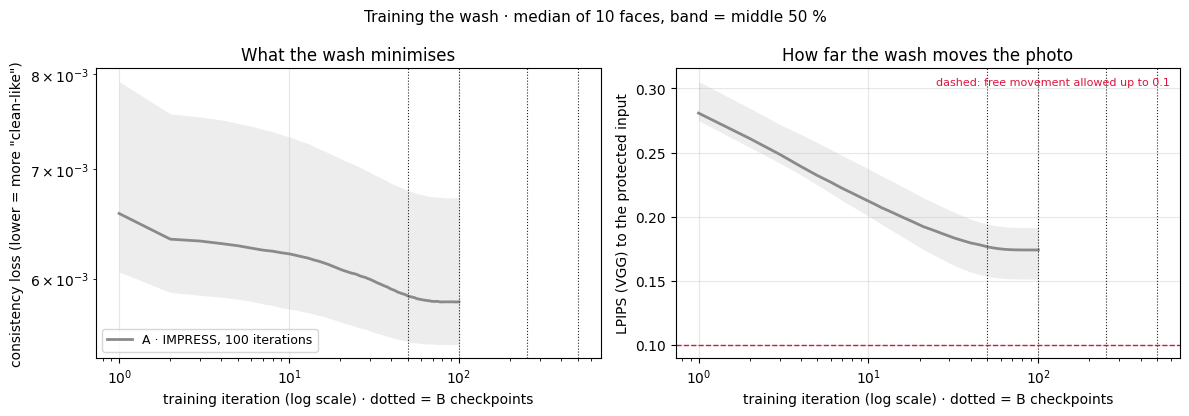

A · IMPRESS, 100 iterations    consistency loss 0.00658 -> 0.00581 (-12%) over 100 iterations
B · IMPRESS, 1000 iterations: not trained yet (Part 2)


In [9]:
# 7 · Training curves, from the log the patched IMPRESS wrote during cell 6.
import matplotlib.pyplot as plt
LABEL = {'N_no_wash': 'N · no wash', 'A_impress_100': 'A · IMPRESS, 100 iterations',
         'C_tyro_masked': 'C · ours: A + mask', 'B_impress_1000': 'B · IMPRESS, 1000 iterations'}
COLOR = {'A_impress_100': '#8a8a8a', 'B_impress_1000': '#222222', 'C_tyro_masked': '#1f6fd1', 'N_no_wash': '#bbbbbb'}

log = read_log().astype({'iter': int, 'loss': float, 'consistency': float, 'dist': float})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ver in ('A_impress_100', 'B_impress_1000'):
    sub = log[log.version == ver]
    if sub.empty: continue
    g = sub.groupby('iter')
    for ax, col in zip(axes, ('consistency', 'dist')):
        med = g[col].median()
        ax.fill_between(med.index, g[col].quantile(.25), g[col].quantile(.75), color=COLOR[ver], alpha=.15, lw=0)
        ax.plot(med.index, med.values, color=COLOR[ver], lw=2, label=LABEL[ver])
for ax in axes:
    for k in SNAP_AT: ax.axvline(k, color='#222222', ls=':', lw=.8)
    ax.set_xscale('log'); ax.set_xlabel('training iteration (log scale) · dotted = B checkpoints'); ax.grid(alpha=.3)
axes[0].set_yscale('log'); axes[0].set_ylabel('consistency loss (lower = more "clean-like")')
axes[0].set_title('What the wash minimises')
axes[1].axhline(PARAMS['pur_eps'], color='crimson', ls='--', lw=1)
axes[1].text(0.98, 0.97, f"dashed: free movement allowed up to {PARAMS['pur_eps']}", transform=axes[1].transAxes,
             ha='right', va='top', color='crimson', fontsize=8)
axes[1].set_ylabel('LPIPS (VGG) to the protected input'); axes[1].set_title('How far the wash moves the photo')
axes[0].legend(fontsize=9)
fig.suptitle(f'Training the wash · median of {log.image.nunique()} faces, band = middle 50 %', fontsize=11)
fig.tight_layout(); fig.savefig(OUT / 'fig1_training_curve.png', dpi=120, bbox_inches='tight'); plt.show()

for ver in ('A_impress_100', 'B_impress_1000'):
    sub = log[log.version == ver]
    if sub.empty: print(f'{LABEL[ver]}: not trained yet (Part {1 if ver.startswith("A") else 2})'); continue
    first, last = (sub[sub.iter == sub.iter.min()].consistency.median(), sub[sub.iter == sub.iter.max()].consistency.median())
    print(f'{LABEL[ver]:<30} consistency loss {first:.5f} -> {last:.5f} ({(last - first) / first:+.0%}) '
          f'over {sub.iter.max()} iterations')

## Result 2 · What does each round of training buy?

Every version, and every checkpoint of B's training, went through the same editor with the same
seed. Each is scored on both axes. **The shield is identical for all of them** (Part 1's protected
photos), so differences come from the wash alone.

How to read it:
- **Left (photo damage):** lower is better. The dashed line is N, the protected photo with no wash.
- **Right (recovery):** higher is better. The grey band is the ±3 pp noise we measured between
  identical runs. A move that stays inside the band is not evidence of anything.
- The black line is **one** training run (B) inspected at its checkpoints. A (grey square) is a
  **separate** 100-iteration run, and it differs from "B at 100": IMPRESS slows its learning rate
  down to finish by the last iteration, so B at iteration 100 is still taking big steps.

In [10]:
# 8 · Score every version and checkpoint against the SAME reference (Part 1's no-wash folder).
import lpips, torch as _t
_net = lpips.LPIPS(net='alex', verbose=False).to(DEVICE).eval()
def lp(pa, pb):
    f = lambda q: (_t.from_numpy(np.asarray(Image.open(q).convert('RGB'), np.float32) / 127.5 - 1)
                   .permute(2, 0, 1)[None].to(DEVICE))
    with _t.no_grad(): return float(_net(f(pa), f(pb)))

REF   = OUT / 'N_no_wash'
assert (REF / 'edit_clean').is_dir(), 'Part 1 results missing: run PART = 1 first'
FACES = sorted(os.listdir(REF / 'edit_clean'))
ITERS = {'N_no_wash': 0, 'A_impress_100': VERSIONS[1][1]['iters'], 'C_tyro_masked': VERSIONS[1][2]['iters'],
         **{f'B_ckpt_{k:04d}': k for k in SNAP_AT}, 'B_impress_1000': VERSIONS[2][0]['iters']}
ORDER = [n for n in ITERS if (OUT / n / 'edit_washed').is_dir()]
DRIFT = 0.010    # measured Colab-vs-Kaggle spread of SSIM; a margin smaller than this is not a margin

rows = []
for name in ORDER:
    for f in FACES:
        adv = ssim_pair(REF / 'edit_protected' / f, REF / 'edit_clean' / f)
        pur = ssim_pair(OUT / name / 'edit_washed' / f, REF / 'edit_clean' / f)
        rows.append(dict(version=name, iters=ITERS[name], face=f, ssim_adv=adv, ssim_pur=pur,
                         R_pipe=100 * (pur - adv) / (1 - adv),
                         damage=lp(OUT / name / 'washed' / f, REF / 'clean512' / f)))
per = pd.DataFrame(rows)

def _summ(g):
    a, p = g.ssim_adv.mean(), g.ssim_pur.mean()
    return pd.Series(dict(iterations=int(g.iters.iloc[0]), photo_damage=g.damage.mean(),
                          recovery=100 * (p - a) / (1 - a),                 # same formula as M2, on the means
                          faces_up=int((g.R_pipe > 3).sum()), faces_down=int((g.R_pipe < -3).sum())))
S = pd.DataFrame({n: _summ(per[per.version == n]) for n in ORDER}).T.astype({'iterations': int, 'faces_up': int, 'faces_down': int})
show = S.copy(); show.index = [LABEL.get(i, f'B · checkpoint at {ITERS[i]}') for i in S.index]
show.columns = ['training iterations', 'photo damage (LPIPS, lower better)', 'recovery R_pipe % (higher better)',
                'faces > +3 pp', 'faces < -3 pp']
display(show.round(3))

# Was the shield noticed at all? (decided once, from N, because the shield is the same for everyone)
n0 = per[per.version == 'N_no_wash'].assign(floor=lambda d: d.face.map(SEED_FLOOR))
noticed = set(n0[n0.ssim_adv < n0.floor - DRIFT].face)
print(f'\nShield noticed by the editor (changed the edit more than a seed change does) on '
      f'{len(noticed)} of {len(n0)} faces' + (f': {", ".join(f.split("_")[0] for f in sorted(noticed))}' if noticed else ''))

# Part 2 ran in a different session. The editor is deterministic, so its clean edits should match Part 1's.
if 'B_impress_1000' in ORDER:
    _d = max(np.abs(np.asarray(Image.open(OUT / 'B_impress_1000' / 'edit_clean' / f), np.int16)
                    - np.asarray(Image.open(REF / 'edit_clean' / f), np.int16)).max() for f in FACES)
    print(f'Part 1 vs Part 2 sessions: largest pixel difference in the clean edits = {_d} grey levels'
          + ('  (identical: the two sessions are directly comparable)' if _d == 0 else ''))

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 211MB/s]  


,training iterations,"photo damage (LPIPS, lower better)",recovery R_pipe % (higher better),faces > +3 pp,faces < -3 pp
N · no wash,0,0.034,0.000,0,0
"A · IMPRESS, 100 iterations",100,0.185,0.221,4,3
C · ours: A + mask,100,0.060,0.942,4,4



Shield noticed by the editor (changed the edit more than a seed change does) on 0 of 10 faces


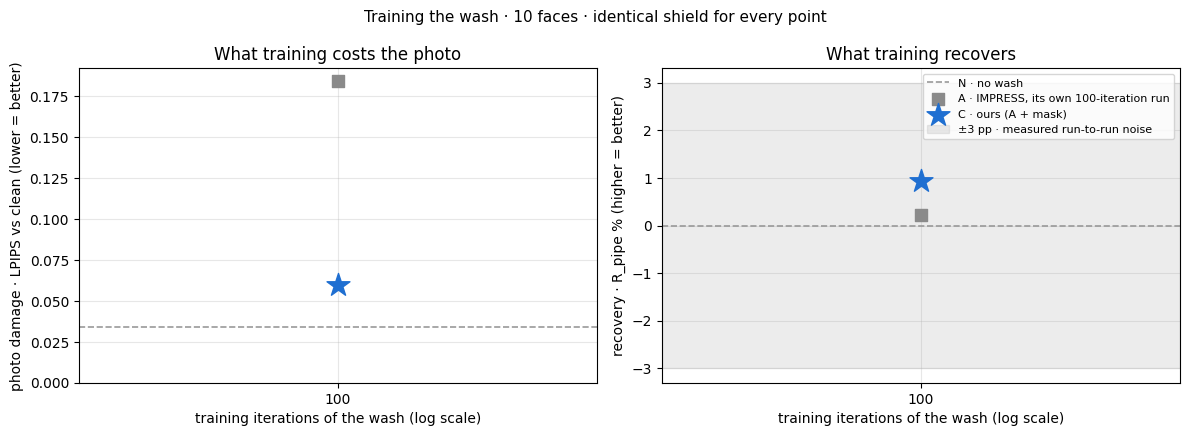

Mask, same training (C vs A): photo damage 0.185 -> 0.060 (-68%); recovery +0.7 pp (inside the noise)
B and its checkpoints appear here after Part 2.


In [11]:
# 9 · The iteration curve: photo damage and recovery against training iterations.
btrain = [n for n in ORDER if n.startswith('B_')]
btrain = sorted(btrain, key=lambda n: ITERS[n])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, col, ylab in ((axes[0], 'photo_damage', 'photo damage · LPIPS vs clean (lower = better)'),
                      (axes[1], 'recovery',     'recovery · R_pipe % (higher = better)')):
    if btrain:
        ax.plot([ITERS[n] for n in btrain], S.loc[btrain, col], 'o-', color=COLOR['B_impress_1000'], lw=2,
                label='B · one 1000-iteration training run, at its checkpoints')
    ax.axhline(S.loc['N_no_wash', col], color='#999999', ls='--', lw=1.2, label='N · no wash')
    if 'A_impress_100' in S.index:
        ax.scatter(ITERS['A_impress_100'], S.loc['A_impress_100', col], marker='s', s=80, color=COLOR['A_impress_100'],
                   zorder=4, label='A · IMPRESS, its own 100-iteration run')
    if 'C_tyro_masked' in S.index:
        ax.scatter(ITERS['C_tyro_masked'], S.loc['C_tyro_masked', col], marker='*', s=300, color=COLOR['C_tyro_masked'],
                   zorder=5, label='C · ours (A + mask)')
    ax.set_xscale('log'); ax.set_xticks(sorted({ITERS[n] for n in ORDER if ITERS[n]}))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter()); ax.minorticks_off()
    ax.set_xlabel('training iterations of the wash (log scale)'); ax.set_ylabel(ylab); ax.grid(alpha=.3)
axes[1].axhspan(-3, 3, color='grey', alpha=.15, label='±3 pp · measured run-to-run noise')
axes[0].set_ylim(bottom=0); axes[0].set_title('What training costs the photo'); axes[1].set_title('What training recovers')
axes[1].legend(fontsize=8, loc='best')
fig.suptitle(f'Training the wash · {len(FACES)} faces · identical shield for every point', fontsize=11)
fig.tight_layout(); fig.savefig(OUT / 'fig2_iteration_curve.png', dpi=120, bbox_inches='tight'); plt.show()

# The conclusions, written by the data rather than by us.
def _noise(x): return 'inside' if abs(x) <= 3 else 'OUTSIDE'
if len(btrain) >= 2:
    a, b = btrain[0], btrain[-1]
    dd, dr = S.loc[b, 'photo_damage'] - S.loc[a, 'photo_damage'], S.loc[b, 'recovery'] - S.loc[a, 'recovery']
    print(f'Training B from {ITERS[a]} to {ITERS[b]} iterations:')
    print(f'  photo damage {S.loc[a, "photo_damage"]:.3f} -> {S.loc[b, "photo_damage"]:.3f}  ({dd / S.loc[a, "photo_damage"]:+.0%})')
    print(f'  recovery     {S.loc[a, "recovery"]:+.1f} -> {S.loc[b, "recovery"]:+.1f} pp  (change {dr:+.1f} pp, {_noise(dr)} the ±3 pp noise)')
if {'A_impress_100', 'C_tyro_masked'} <= set(S.index):
    A_, C_ = S.loc['A_impress_100'], S.loc['C_tyro_masked']
    print(f'Mask, same training (C vs A): photo damage {A_.photo_damage:.3f} -> {C_.photo_damage:.3f} '
          f'({(C_.photo_damage - A_.photo_damage) / A_.photo_damage:+.0%}); '
          f'recovery {C_.recovery - A_.recovery:+.1f} pp ({_noise(C_.recovery - A_.recovery)} the noise)')
if {'B_impress_1000', 'C_tyro_masked'} <= set(S.index):
    B_ = S.loc['B_impress_1000']
    print(f'Ours vs 10x the training (C vs B): photo damage {C_.photo_damage:.3f} vs {B_.photo_damage:.3f}; '
          f'recovery {C_.recovery - B_.recovery:+.1f} pp ({_noise(C_.recovery - B_.recovery)} the noise)')
if not btrain: print('B and its checkpoints appear here after Part 2.')

## Result 3 · All ten faces, side by side

One row per face, the same seed, prompt (*"a person in an airplane"*) and mask in every panel.
Read each row left to right: the **target** is the edit of the clean photo (column 2); a good wash
makes its edit look like the target, and leaves the photo itself undamaged. Under each washed edit:
the photo damage of that wash, and its recovery score for that face. Faces where the shield was
noticed are outlined in blue.

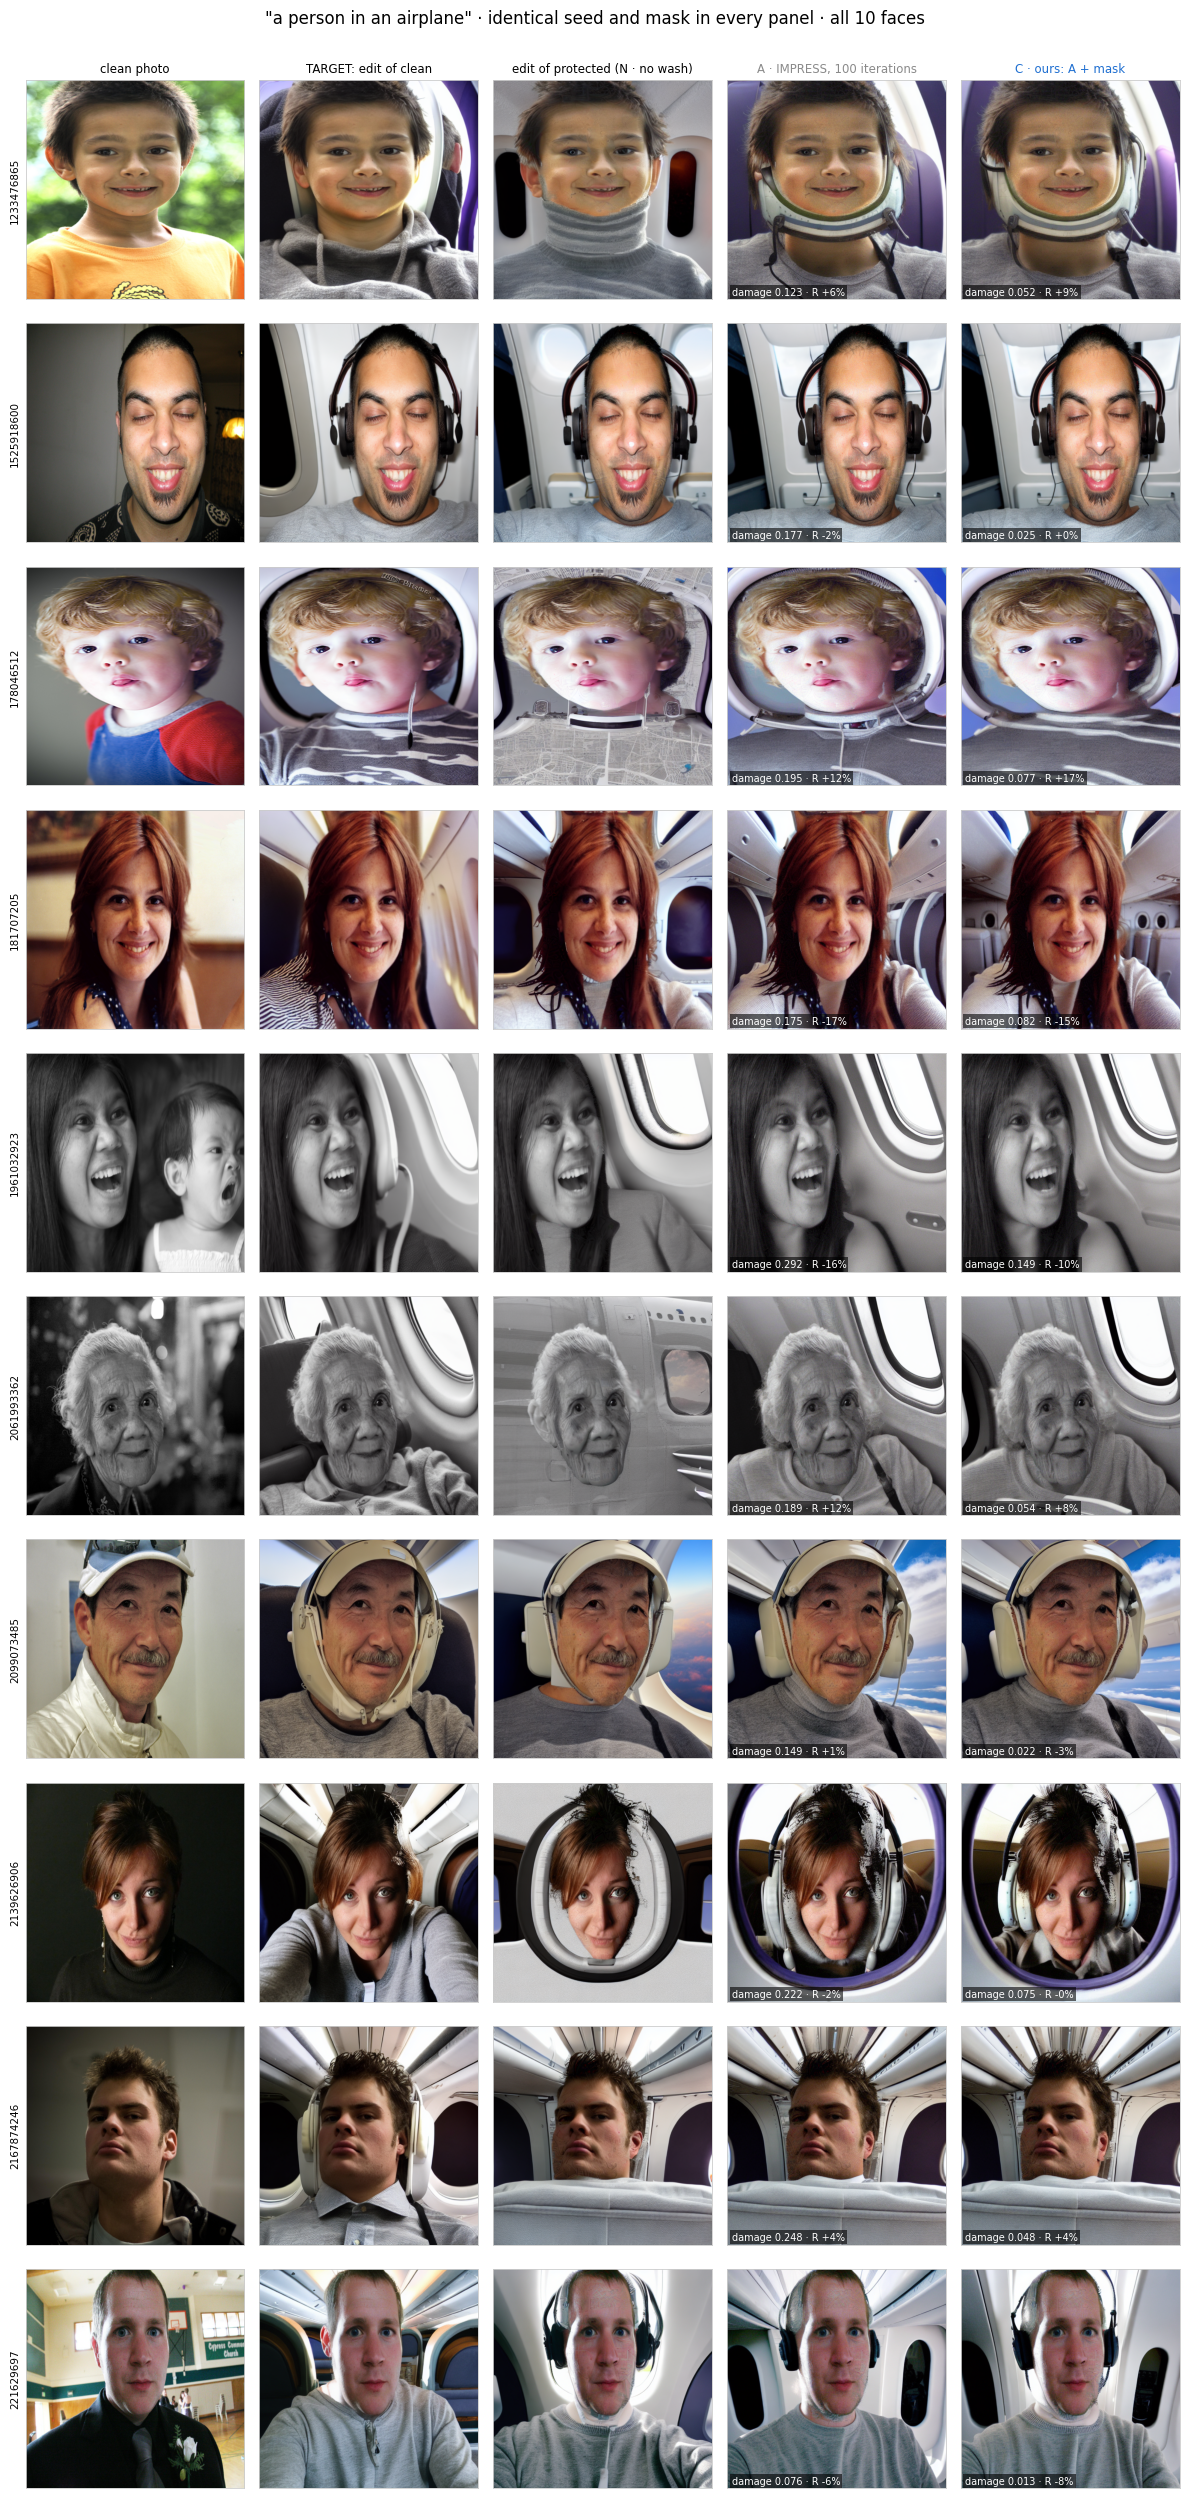

In [12]:
# 10 · The long comparison figure: ten faces x every version.
cols = [('clean photo', REF, 'clean512', None), ('TARGET: edit of clean', REF, 'edit_clean', None),
        ('edit of protected (N · no wash)', REF, 'edit_protected', None)]
cols += [(LABEL[n], OUT / n, 'edit_washed', n) for n in ('A_impress_100', 'B_impress_1000', 'C_tyro_masked') if n in ORDER]

fig, axes = plt.subplots(len(FACES), len(cols), figsize=(2.4 * len(cols), 2.5 * len(FACES)))
axes = np.atleast_2d(axes)
for r, f in enumerate(FACES):
    hit = f in noticed
    for c, (title, d, sub, ver) in enumerate(cols):
        ax = axes[r, c]; ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(Image.open(d / sub / f))
        if r == 0: ax.set_title(title, fontsize=8.5, color=COLOR.get(ver, 'black'))
        if c == 0: ax.set_ylabel(f.split('_')[0] + ('\nshield noticed' if hit else ''), fontsize=7.5)
        if ver:
            q = per[(per.version == ver) & (per.face == f)].iloc[0]
            ax.text(0.02, 0.02, f'damage {q.damage:.3f} · R {q.R_pipe:+.0f}%', transform=ax.transAxes, fontsize=7,
                    color='white', bbox=dict(facecolor='black', alpha=.6, pad=1.5, lw=0))
        for s in ax.spines.values():
            s.set_color('#1f6fd1' if hit else '#cccccc'); s.set_linewidth(2 if hit else .6)
fig.suptitle(f'"{PARAMS["prompt"]}" · identical seed and mask in every panel · all {len(FACES)} faces', fontsize=12, y=1.0)
fig.tight_layout(); fig.savefig(OUT / 'fig3_all_faces.png', dpi=100, bbox_inches='tight'); plt.show()

In [13]:
# 11 · One face through B's training: the washed photo and its edit at every checkpoint.
PROGRESS_FACE = sorted(noticed)[0] if noticed else FACES[0]     # the face where the shield was noticed, if any
steps = [('protected (0)', REF, 'protected', 'edit_protected')] + \
        [(f'iteration {ITERS[n]}', OUT / n, 'washed', 'edit_washed') for n in btrain]
if len(steps) > 1:
    fig, axes = plt.subplots(2, len(steps) + 1, figsize=(2.3 * (len(steps) + 1), 5))
    for c, (title, d, ph, ed) in enumerate(steps + [('clean (target)', REF, 'clean512', 'edit_clean')]):
        for r, sub in enumerate((ph, ed)):
            ax = axes[r, c]; ax.set_xticks([]); ax.set_yticks([]); ax.imshow(Image.open(d / sub / PROGRESS_FACE))
        axes[0, c].set_title(title, fontsize=9)
    axes[0, 0].set_ylabel('washed photo', fontsize=9); axes[1, 0].set_ylabel('its edit', fontsize=9)
    fig.suptitle(f'Face {PROGRESS_FACE.split("_")[0]} through one 1000-iteration training run (B)', fontsize=11)
    fig.tight_layout(); fig.savefig(OUT / 'fig4_training_progress_one_face.png', dpi=110, bbox_inches='tight'); plt.show()
else:
    print('This figure appears after Part 2 (it needs B\'s checkpoints).')

This figure appears after Part 2 (it needs B's checkpoints).


## What Part 1 found

- **Our mask cuts photo damage by 68 % at the same cost:** C 0.060 vs A 0.185 (no wash: 0.034).
- **It does not change recovery:** +0.7 pp over A, inside the ±3 pp noise.
- **The shield was weak:** on all 10 faces it changed the edit less than a change of random seed.

**Part 2** adds the 1000-iteration version B with its training checkpoints, and draws every figure
with all four versions.

## Why this shield setting — and why the shield sweep tested only three points

The shield is held at **M2's setting** (`eps 16, step 1`, 40 iterations × 2) so this notebook varies
**only the wash**. In plain words, the shield has two knobs: `eps` is the **fence** (the largest total
change PhotoGuard may make) and `step` is the **stride** (how far it moves per iteration).

We did try to make the shield stronger first, because a weak shield leaves the wash little to
remove. Across three earlier runs we tested **seven** settings, not three:

| shield (eps, step) | run | faces | shield noticed | what it showed |
|---|---|---:|---:|---|
| 16, 1 · **M2 setting** | 25 Sep, Colab | 10 | 1 | the starting point |
| 32, 1 | 9 Sep, Kaggle | 2 | 0 | identical to eps 16: at stride 1 the shield never reaches the fence, so the fence does nothing |
| 16, 2 | 19 Sep, Kaggle | 10 | 1 | |
| 16, 4 | 19 Sep, Kaggle | 10 | 1 | |
| 16, 8 | 19 Sep, Kaggle | 10 | 1 | a longer stride **re-shuffles** the noise but does not aim it: 0 of 10 faces improved steadily |
| 64, 4 | 19 & 27 Sep | 10 | 2 | once the stride reaches the fence, a wider fence helps a little, but the photo damage triples (LPIPS 0.027 → 0.096) |
| 256, 4 | 19 & 27 Sep | 10 | 1 | saturated: the noise stopped growing (+0.1 % vs eps 64) |

The final Colab sweep (`Dark_Tyro_M3_sweep_0927_Colab.ipynb`) re-measured only **three** of these
because three points are enough to draw the curve: the **start** (16, 1), the point where the fence
**starts to matter** (64, 4), and where it **stops mattering** (256, 4). The stride rows were
already settled and each extra row costs about 40 GPU minutes. Even the strongest setting was
noticed on at most 2 of 10 faces, while damaging the photo more than our own 0.10 budget on 3 of 10.
So a stronger shield would not have given the wash a fairer test, and we kept M2's setting.

**One limit we state openly:** our shield runs 40 × 2 iterations, 1/25 of the reference 200 × 10,
because the reference setting needs about 13 GPU hours for ten faces.

## Limitations

1. **The shield is weak at this setting** (noticed on 0 of 10 faces in this run, 1 of 10 in earlier runs), so the recovery score
   has little damage to measure and mostly sits inside its ±3 pp noise. **Photo damage is the
   reliable axis**: it reproduces to three decimals between identical runs.
2. **The checkpoints come from one training run.** IMPRESS lowers its learning rate on a schedule
   fixed by the total number of iterations, so "B at iteration 100" is not the same photo as A
   (a complete 100-iteration run). Both are shown for that reason.
3. **n = 10 faces, one prompt, one editor** (Stable Diffusion 1.5 inpainting). The claims are about
   this benchmark, not about PhotoGuard in general.
4. **The mask is an input.** Our method needs to know which region the editor will repaint. An
   inpainting attacker always does, but the method does not transfer to whole-image protections.

In [14]:
# 12 · Collect: one small zip with the tables, the training log and the figures (no photo folders).
REPORT = OUT / f'REPORT_part{PART}'
shutil.rmtree(REPORT, ignore_errors=True); REPORT.mkdir()
per.round(5).to_csv(REPORT / 'per_face.csv', index=False)
S.round(5).to_csv(REPORT / 'summary.csv')
shutil.copy(TRAIN_LOG, REPORT / TRAIN_LOG.name)
for fig_png in OUT.glob('fig*.png'): shutil.copy(fig_png, REPORT / fig_png.name)
zp = shutil.make_archive(str(REPORT), 'zip', root_dir=str(REPORT))
if DRIVE_DIR: shutil.copy(zp, DRIVE_DIR / os.path.basename(zp))
print(f'{os.path.basename(zp)} ({os.path.getsize(zp) / 1e6:.1f} MB):', sorted(os.listdir(REPORT)))
if PLATFORM == 'kaggle': print('Kaggle: the files appear in the Output tab after Save Version (Save & Run All).')

REPORT_part1.zip (4.5 MB): ['fig1_training_curve.png', 'fig2_iteration_curve.png', 'fig3_all_faces.png', 'per_face.csv', 'summary.csv', 'training_log.csv']
Kaggle: the files appear in the Output tab after Save Version (Save & Run All).
